## Desafio 3 — Rastreamento de Objetos com YOLO

A diferença entre detecção e rastreamento é que o tracking mantém um ID consistente para cada objeto ao longo dos frames. Em vez de só saber "tem uma pessoa aqui", passa a saber "essa é a pessoa #3 que apareceu no frame 10".

O `model.track()` da Ultralytics faz isso de forma bem direta — por baixo usa o algoritmo BoT-SORT ou ByteTrack para associar detecções entre frames.

### Instalação e Importação da Biblioteca

In [1]:
!pip install ultralytics opencv-python torch

In [2]:
import ultralytics
import cv2
import torch

### Processar dados

O `conf=0.1` baixo captura mais objetos com menor certeza — faz sentido para tracking, onde é melhor ter mais candidatos e o algoritmo de associação filtra os ruins. O `iou=0.7` controla a sobreposição entre bounding boxes para suprimir duplicatas.

In [3]:
# Baixa o modelo
model = ultralytics.YOLO("yolo11n.pt")

# Jogao o modelo para o dispositivo de computação
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# processa o vídeo
video_path = "../../assets/modulo5/video.mov"
results = model.track(source=video_path, conf=0.1, iou=0.7)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/239) /Users/larry/Documents/Dev/Residencia/Jupyter Notebooks/DesafiosExtras/Desafio3/../../assets/modulo5/video.mov: 384x640 1 apple, 1 orange, 41.7ms
video 1/1 (frame 2/239) /Users/larry/Documents/Dev/Residencia/Jupyter Notebooks/DesafiosExtras/Desafio3/../../assets/modulo5/video.mov: 384x640 1 apple, 1 orange, 39.6ms
video 1/1 (frame 3/239) /Users/larry/Documents/Dev/Residencia/Jupyter Notebooks/DesafiosExtras/Desafio3/../../assets/m

### Salvar Vídeo

O `r.plot()` retorna um frame BGR com as anotações desenhadas — bounding boxes, labels e IDs de tracking. O `VideoWriter` grava esses frames num arquivo `.avi`.

In [4]:
# validar resultados
for r in results:
    print(r)

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [6]:
# Cria o escritor do vídeo de output
# Você pode pesquisar para salvar em outros formatos
first_frame = results[0].plot()
h, w = first_frame.shape[:2]
writer = cv2.VideoWriter("output.avi", cv2.VideoWriter_fourcc(*"XVID"), 20, (w, h))

# Escreve o vídeo de output
writer.write(first_frame)
for r in results[1:]:
    writer.write(r.plot())
writer.release()

### Visualizar Resultado

Mostra três frames do vídeo com as anotações de tracking — início, meio e fim.

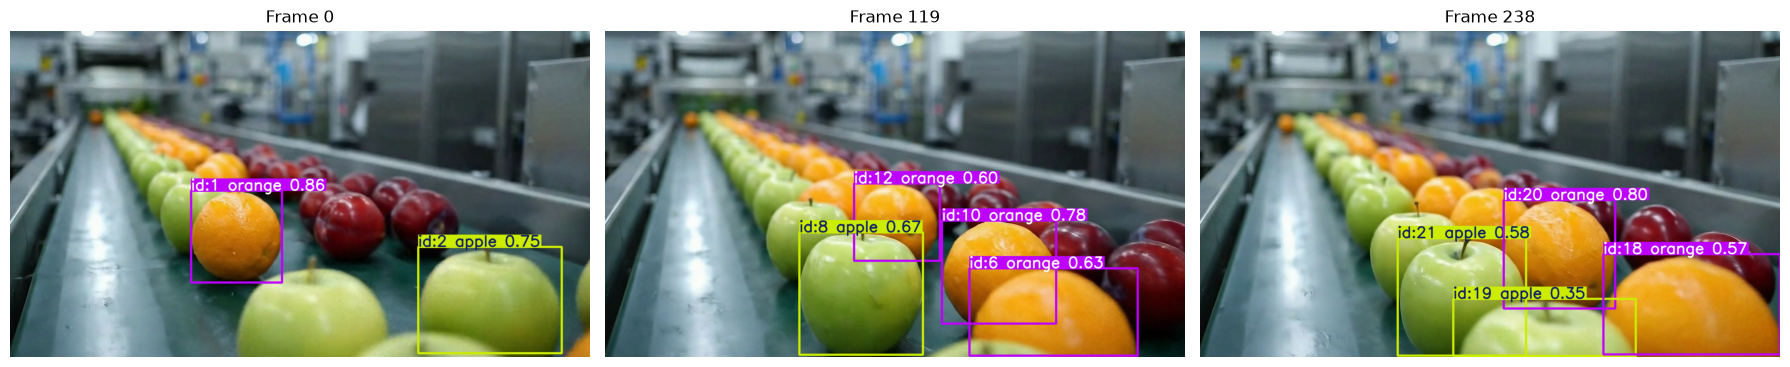

In [7]:
import matplotlib.pyplot as plt

indices = [0, len(results) // 2, len(results) - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, i in zip(axes, indices):
    frame = cv2.cvtColor(results[i].plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(frame)
    ax.set_title(f"Frame {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Referência

- https://docs.ultralytics.com/modes/track/